| Region                          | Found for                                      | Novelty / Interpretation                                                                                                                                                                                                 |
|---------------------------------|------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Left Angular Gyrus              | Both RPE and Shannon Surprise                  | This region consistently tracked both computations — rarely reported in unisensory learning meta-analyses. Suggested as a hub integrating structure (SL) and value (RL) across senses. Most prior RL/SL meta-analyses report inferior/superior parietal lobule, not angular gyrus. |
| Precuneus                       | Shannon Surprise (SL)                          | Not typically found in prior SL studies (which emphasize inferior/superior parietal or frontal regions). Here, it may encode multisensory statistical surprise, possibly reflecting higher-order integration or self-referential monitoring of multisensory structure. |
| Middle Frontal Gyrus (MFG) and Orbital Inferior Frontal Gyrus (IFGorb) | Unsigned RPE (uRPE) | These were not commonly reported in unisensory uRPE meta-analyses (which usually show striatum, insula, dmPFC, IPL). Their engagement here suggests extended frontal recruitment for multisensory outcome surprise and cognitive control.                     |
| Lateral Frontoparietal Network (incl. SFS, IPL) | uRPE | While IPL is sometimes implicated in uRPE, the broad lateral frontoparietal spread seen here exceeds typical unisensory findings — indicating greater attentional/salience control demands in multisensory contexts. |


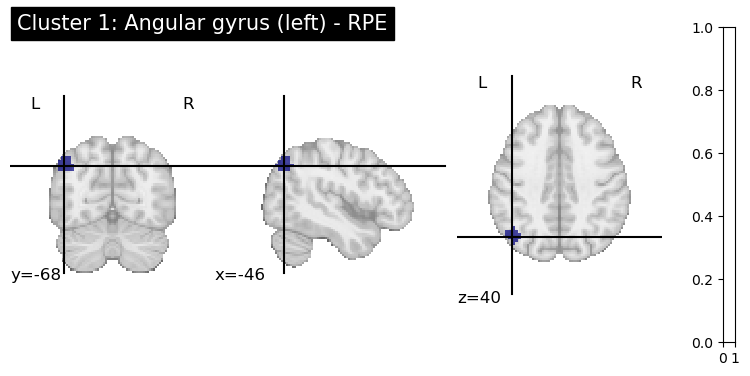

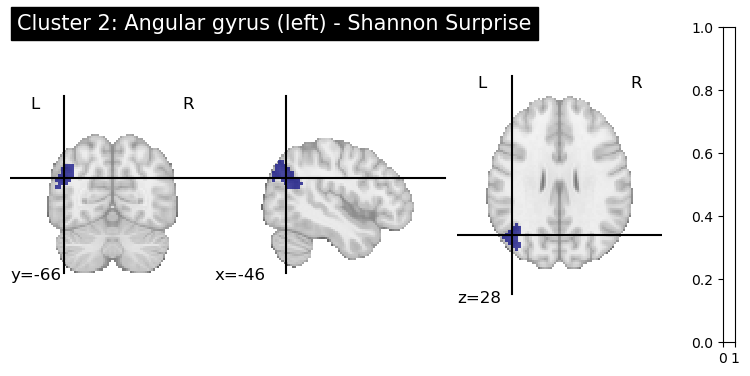

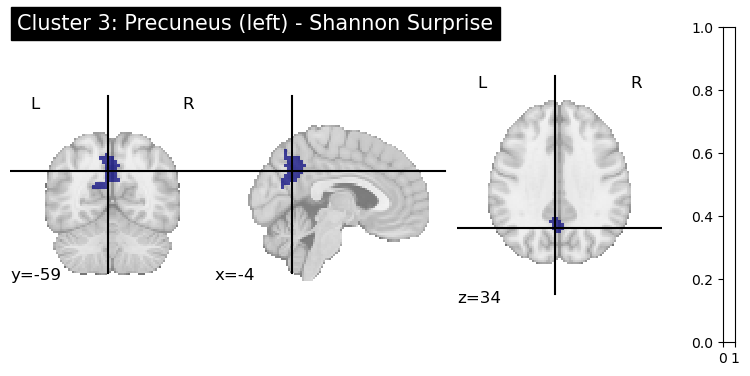

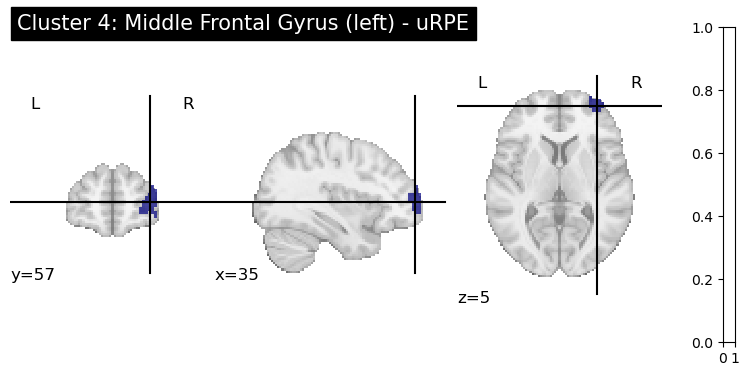

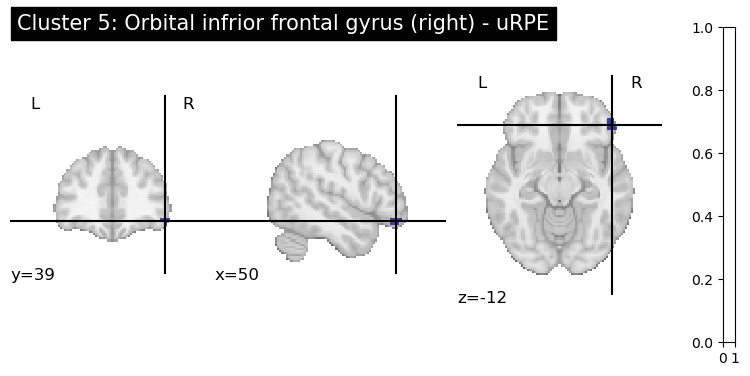

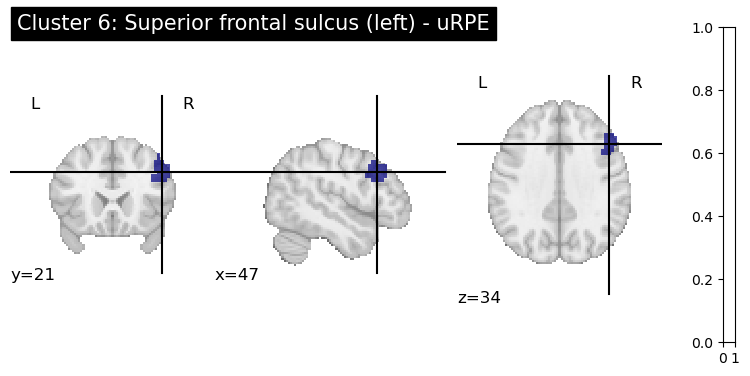

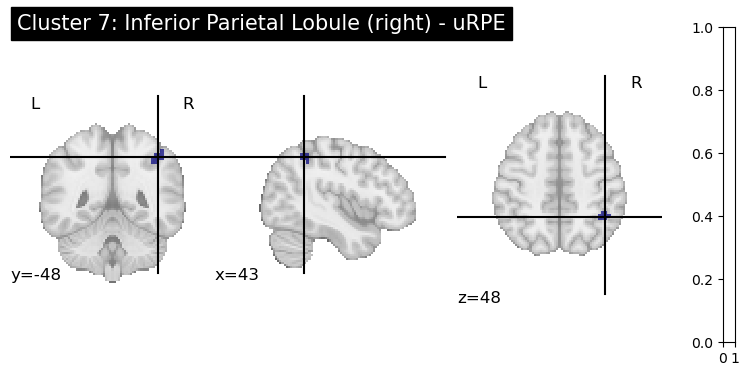

In [18]:
from pathlib import Path
from nilearn import image, plotting

bids_folder = Path('/data/ds-mlearn/')

# base_dir = root_folder / 'nipype' / 'model2' 

cluster1 = image.load_img(bids_folder / 'nipype' / 'model2' / 'ROI' / f'cluster_3_con1_8_0_pos.nii') # LaG RPE
cluster2 = image.load_img(bids_folder / 'nipype' / 'model2' / 'ROI' / f'cluster_4_con5_3_1_pos.nii')
cluster3 = image.load_img(bids_folder / 'nipype' / 'model2' / 'ROI' / f'cluster_1_con5_3_1_pos.nii') 
cluster4 = image.load_img(bids_folder / 'nipype' / 'model7' / 'ROI' / f'cluster_4_con1_4_0_pos.nii')
cluster5 = image.load_img(bids_folder / 'nipype' / 'model7' / 'ROI' / f'cluster_6_con1_4_0_pos.nii')
cluster6 = image.load_img(bids_folder / 'nipype' / 'model7' / 'ROI' / f'cluster_7_con1_4_0_pos.nii')
cluster7 = image.load_img(bids_folder / 'nipype' / 'model7' / 'ROI' / f'cluster_8_con1_4_0_pos.nii')

# clusters2 # LaG Shannon Surprise

plotting.plot_roi(cluster1, title='Cluster 1: Angular gyrus (left) - RPE')
plotting.plot_roi(cluster2, title='Cluster 2: Angular gyrus (left) - Shannon Surprise')
plotting.plot_roi(cluster3, title='Cluster 3: Precuneus (left) - Shannon Surprise')
plotting.plot_roi(cluster4, title='Cluster 4: Middle Frontal Gyrus (left) - uRPE')
plotting.plot_roi(cluster5, title='Cluster 5: Orbital infrior frontal gyrus (right) - uRPE')
plotting.plot_roi(cluster6, title='Cluster 6: Superior frontal sulcus (left) - uRPE')
plotting.plot_roi(cluster7, title='Cluster 7: Inferior Parietal Lobule (right) - uRPE')


cluster_labels = ['Angular gyrus (left) - RPE', 'Angular gyrus (left) - Shannon Surprise', 'Precuneus (left) - Shannon Surprise',
                  'Middle Frontal Gyrus (left) - uRPE', 'Orbital infrior frontal gyrus (right) - uRPE',
                  'Superior frontal sulcus (left) - uRPE', 'Inferior Parietal Lobule (right) - uRPE']

In [19]:
# RPE: model 2, Contrast 1
# Surprise: model 2, Contrast 5
# uRPE: model 7, Contrast 1

In [20]:
from nilearn.input_data import NiftiMasker
root_folder = Path('/data/ds-mlearn')

subjects = range(1,65)
subjects = [str(sub).zfill(2) for sub in subjects if sub not in [8, 13, 16, 31, 32, 44]]

clusters = [cluster1, cluster2, cluster3, cluster4, cluster5, cluster6, cluster7]

def get_mean_beta(subject, cluster, contrast):
    cluster = clusters[cluster - 1]

    assert contrast in ['RPE', 'Surprise', 'uRPE'], "Contrast must be one of 'RPE', 'Surprise', or 'uRPE'"

    if contrast == 'RPE':
        model = 'model2'
        contrast_num = 1
    elif contrast == 'Surprise':
        model = 'model2'
        contrast_num = 5
    elif contrast == 'uRPE':
        model = 'model7'
        contrast_num = 1

    fn = root_folder / 'nipype' / model / '1stLevel' / f'sub-{subject}' / f'con_{contrast_num:04d}.nii'
    masker = NiftiMasker(mask_img=cluster)
    return masker.fit_transform(fn).mean()

    

In [37]:
from tqdm.contrib.itertools import product
import pandas as pd

beta_means = []

for subject, cluster, contrast in product(subjects, list(range(1,8)), ['RPE', 'Surprise', 'uRPE']):
    mean_beta = get_mean_beta(subject, cluster, contrast)
    beta_means.append({
        'subject': subject,
        'cluster_label': cluster_labels[cluster - 1],
        'contrast': contrast,
        'mean_beta': mean_beta
    })

betas = pd.DataFrame(beta_means)


100%|██████████| 1218/1218 [06:58<00:00,  2.91it/s]


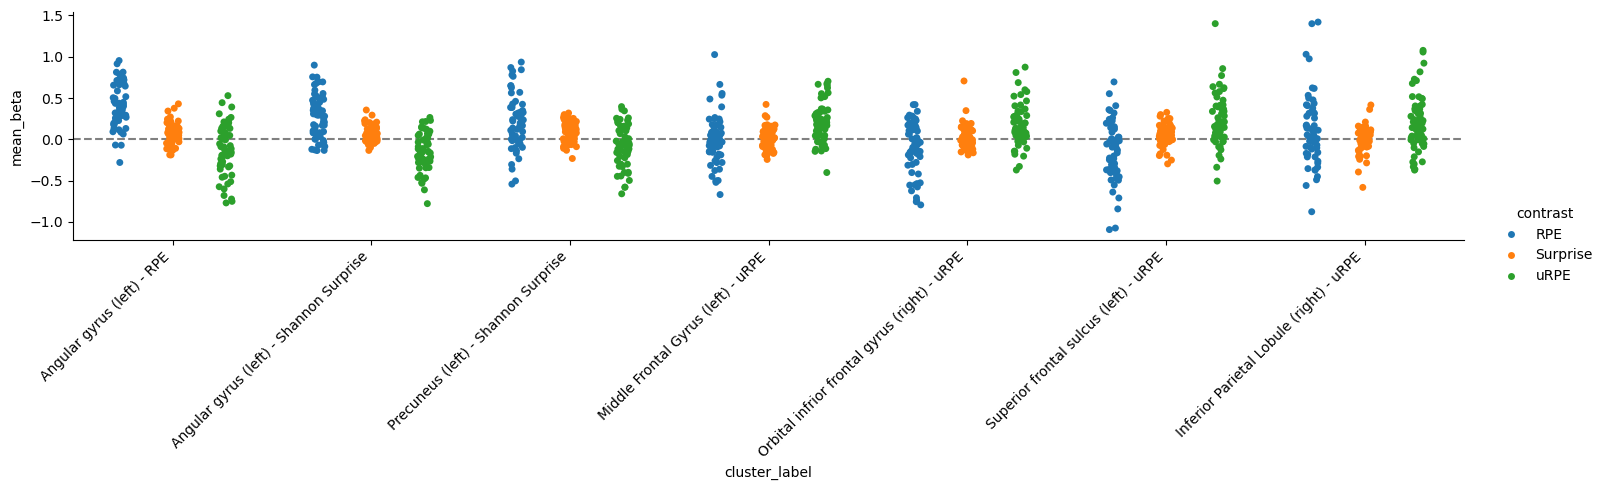

In [38]:
import seaborn as sns
g = sns.catplot(x='cluster_label', y='mean_beta', hue='contrast', data=betas, kind='strip', aspect=3, dodge=True)

# rotate xticks
import matplotlib.pyplot as plt
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

g.map(plt.axhline, y=0, ls='--', c='gray')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_33663/745065347.py:31: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_33663/745065347.py:31: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(


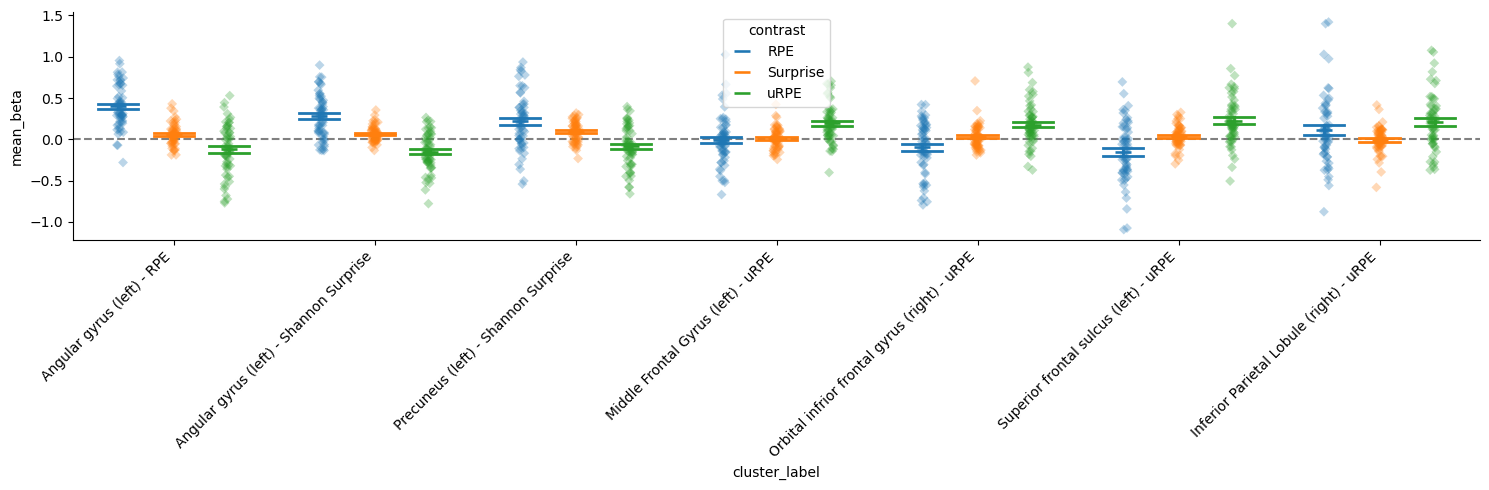

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the strip plot with diamonds and transparency
g = sns.catplot(
    x='cluster_label',
    y='mean_beta',
    hue='contrast',
    data=betas,
    kind='strip',
    aspect=3,
    dodge=True,
    jitter=0.05,         # Reduce jitter for tighter grouping
    alpha=0.3,          # Transparency for points
    marker='D',         # Diamond markers
    size=5,             # Marker size
    legend=False,
)

# Rotate x-axis labels
g.set_xticklabels(rotation=45, ha='right')

# Add a horizontal line at y=0
g.map(plt.axhline, y=0, ls='--', c='gray')

# Calculate the dodge offset for pointplot to match strip plot
n_hues = len(betas['contrast'].unique())
dodge_width = 1.1 / n_hues  # Default dodge width for catplot

# Overlay means with standard error bars
sns.pointplot(
    x='cluster_label',
    y='mean_beta',
    hue='contrast',
    data=betas,
    dodge=dodge_width * 1.5,  # Increase dodge to shift means more laterally
    errorbar='se',      # Standard error
    join=False,         # No connecting lines
    capsize=0.2,        # Cap size for error bars
    errwidth=2.0,       # Thicker error bars
    ax=g.ax,
    legend=True,       # Disable legend for pointplot
    markers='_',        # Horizontal line for mean
    linestyles='',      # No connecting lines
    markersize=12,      # Larger marker size for the mean line
    linewidth=2.5,      # Thicker line for the mean
)

# Adjust legend and layout
# handles, labels = g.ax.get_legend_handles_labels()
# g.ax.legend(handles[:n_hues], labels[:n_hues])  # Keep only unique legend entries
plt.tight_layout()
plt.show()


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_33663/1578505582.py:31: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_33663/1578505582.py:31: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  g = sns.pointplot(


[(-0.4, 0.6)]

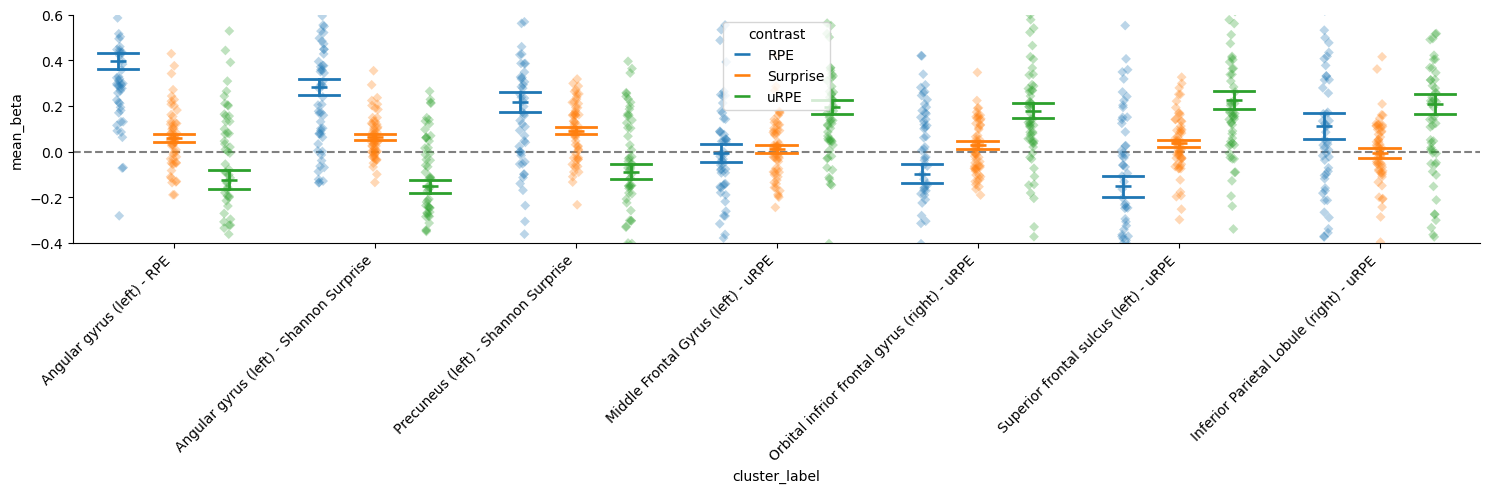

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the strip plot with diamonds and transparency
g = sns.catplot(
    x='cluster_label',
    y='mean_beta',
    hue='contrast',
    data=betas,
    kind='strip',
    aspect=3,
    dodge=True,
    jitter=0.05,         # Reduce jitter for tighter grouping
    alpha=0.3,          # Transparency for points
    marker='D',         # Diamond markers
    size=5,             # Marker size
    legend=False,
)

# Rotate x-axis labels
g.set_xticklabels(rotation=45, ha='right')

# Add a horizontal line at y=0
g.map(plt.axhline, y=0, ls='--', c='gray')

# Calculate the dodge offset for pointplot to match strip plot
n_hues = len(betas['contrast'].unique())
dodge_width = 1.1 / n_hues  # Default dodge width for catplot

# Overlay means with standard error bars
g = sns.pointplot(
    x='cluster_label',
    y='mean_beta',
    hue='contrast',
    data=betas,
    dodge=dodge_width * 1.5,  # Increase dodge to shift means more laterally
    errorbar='se',      # Standard error
    join=False,         # No connecting lines
    capsize=0.2,        # Cap size for error bars
    errwidth=2.0,       # Thicker error bars
    ax=g.ax,
    legend=True,       # Disable legend for pointplot
    markers='_',        # Horizontal line for mean
    linestyles='',      # No connecting lines
    markersize=12,      # Larger marker size for the mean line
    linewidth=2.5,      # Thicker line for the mean
)

# Adjust legend and layout
# handles, labels = g.ax.get_legend_handles_labels()
# g.ax.legend(handles[:n_hues], labels[:n_hues])  # Keep only unique legend entries
plt.tight_layout()

g.set(ylim=(-.4, .6))